<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [5]:
!pip -q install kagglehub pandas numpy matplotlib seaborn scikit-learn

### 2. Импортируем датасет

In [6]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

try:
    import kagglehub
    titanic_path = kagglehub.competition_download('titanic')
    data = pd.read_csv(os.path.join(titanic_path, 'train.csv'))
except Exception:
    data = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

Размер датасета: (891, 12)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Пропущенные значения:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


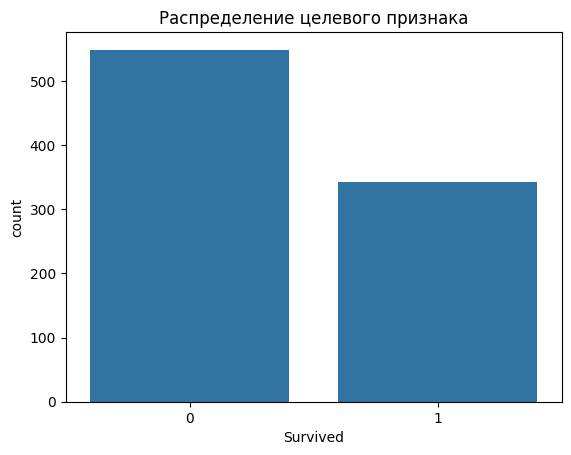

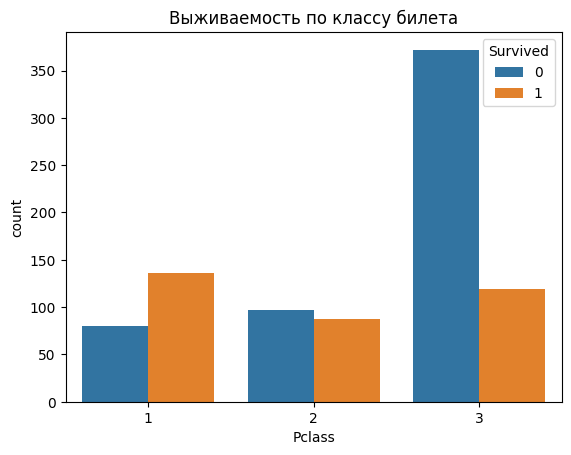

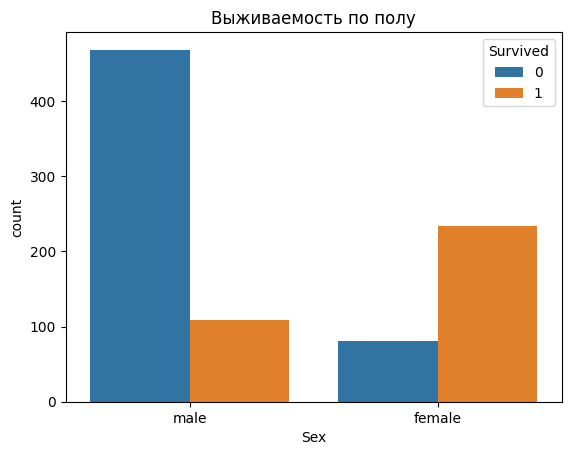

In [7]:
print('Размер датасета:', data.shape)
print('\nИнформация о данных:')
data.info()

print('\nПропущенные значения:')
display(data.isna().sum())

display(data.describe(include='all'))

sns.countplot(data=data, x='Survived')
plt.title('Распределение целевого признака')
plt.show()

sns.countplot(data=data, x='Pclass', hue='Survived')
plt.title('Выживаемость по классу билета')
plt.show()

sns.countplot(data=data, x='Sex', hue='Survived')
plt.title('Выживаемость по полу')
plt.show()

### 4. Сформируем обучающую и тестовую выборки:


In [8]:
X = data.drop('Survived', axis=1)
y = data['Survived']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Обучающая выборка:', X_train_raw.shape)
print('Тестовая выборка:', X_test_raw.shape)

Обучающая выборка: (712, 11)
Тестовая выборка: (179, 11)


### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [9]:
def prepare_titanic_features(df):
  df = df.copy()
  df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
  df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
  df['HasCabin'] = df['Cabin'].notna().astype(int)
  df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
  df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
  df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

  features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'HasCabin']
  return df[features]

X_train = prepare_titanic_features(X_train_raw)
X_test = prepare_titanic_features(X_test_raw)

numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']
categorical_features = ['Sex', 'Embarked', 'Title']

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,HasCabin
692,3,male,NaN,0,0,56.4958,S,1,1,Mr,0
481,2,male,NaN,0,0,0.0000,S,1,1,Mr,0
527,1,male,NaN,0,0,221.7792,S,1,1,Mr,1
855,3,female,18.0,0,1,9.3500,S,2,0,Mrs,0
801,2,female,31.0,1,1,26.2500,S,3,0,Mrs,0


### 6. Построение базовой модели:

In [10]:
rf_base = Pipeline(steps=[('preprocess', preprocessor), ('model', RandomForestClassifier(n_estimators=100, random_state=42))])
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [11]:
def show_classification_result(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Предсказано')
  plt.ylabel('Фактически')
  plt.title('Матрица ошибок')
  plt.show()
  print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
  print('F1-score:', round(f1_score(y_test, y_pred), 4))
  print('\nОтчет классификации:')
  print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

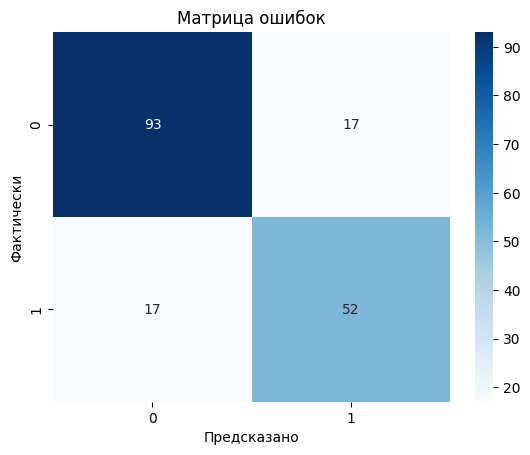

Accuracy: 0.8101
F1-score: 0.7536

Отчет классификации:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.75      0.75      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [12]:
show_classification_result(y_pred_base, y_test)

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [13]:
param_distributions = {
    'model__n_estimators': [50, 100, 150, 200, 300],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
    }

rf_for_random = Pipeline(steps=[('preprocess', preprocessor), ('model', RandomForestClassifier(random_state=42))])

random_search = RandomizedSearchCV(
    estimator=rf_for_random,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
    )

random_search.fit(X_train, y_train)

print('Лучшие параметры RandomSearchCV:')
print(random_search.best_params_)
print('Лучшая accuracy на CV:', round(random_search.best_score_, 4))

Лучшие параметры RandomSearchCV:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 5}
Лучшая accuracy на CV: 0.8287


#### GridSearchCV

In [14]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt']
}

rf_for_grid = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Лучшие параметры GridSearchCV:')
print(grid_search.best_params_)
print('Лучшая accuracy на CV:', round(grid_search.best_score_, 4))

rf_best = grid_search.best_estimator_

Лучшие параметры GridSearchCV:
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Лучшая accuracy на CV: 0.8287


### 9. Комплексная оценка точности лучшей модели:

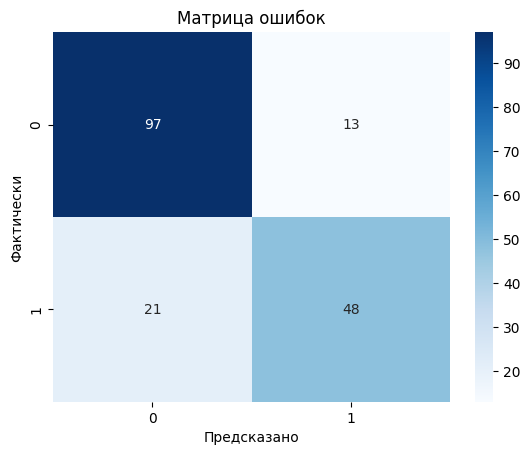

Accuracy: 0.8101
F1-score: 0.7385

Отчет классификации:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC: 0.8548


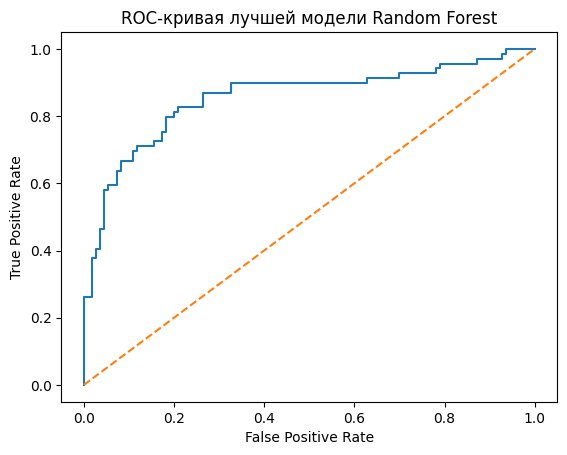

Средняя accuracy на кросс-валидации: 0.8287


In [15]:
y_pred_best = rf_best.predict(X_test)
y_proba_best = rf_best.predict_proba(X_test)[:, 1]

show_classification_result(y_pred_best, y_test)

print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_best), 4))

fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая лучшей модели Random Forest')
plt.show()

cv_scores = cross_val_score(rf_best, X_train, y_train, cv=5, scoring='accuracy')
print('Средняя accuracy на кросс-валидации:', round(cv_scores.mean(), 4))

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [16]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('scale', StandardScaler(with_mean=False)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('scale', StandardScaler(with_mean=False)),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVC': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('scale', StandardScaler(with_mean=False)),
        ('model', SVC(random_state=42))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    'Random Forest': rf_best
}

compare_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    compare_results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1-score': f1_score(y_test, pred)
    })

compare_df = pd.DataFrame(compare_results).sort_values(by='Accuracy', ascending=False)
display(compare_df)

best_name = compare_df.iloc[0]['Модель']
print('Лучшая модель по accuracy:', best_name)

,Модель,Accuracy,F1-score
0,Logistic Regression,0.837989,0.785185
2,SVC,0.832402,0.776119
4,Gradient Boosting,0.826816,0.759690
5,Random Forest,0.810056,0.738462
1,KNN,0.798883,0.731343
3,Decision Tree,0.787709,0.728571


Лучшая модель по accuracy: Logistic Regression


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [17]:
def _input_int(text, min_value, max_value):
    while True:
        try:
            value = int(input(text))
            if min_value <= value <= max_value:
                return value
            print('Ошибка, значение должно быть от', min_value, 'до', max_value)
        except ValueError:
            print('Ошибка, нужно целое число')

def _input_float(text, min_value, max_value):
    while True:
        try:
            value = float(input(text))
            if min_value <= value <= max_value:
                return value
            print('Ошибка, значение должно быть от', min_value, 'до', max_value)
        except ValueError:
            print('Ошибка, нужно целое число')

def _input_choice(text, choices):
    while True:
        value = input(text).strip()
        if value in choices:
            return value
        print('Ошибка, можно ввести только:', ', '.join(choices))

def predict_titanic_passenger(model):
    print('Введите данные пассажира Титаника')

    pclass = _input_int('Класс билета Pclass (1, 2 или 3): ', 1, 3)
    sex = _input_choice('Пол Sex (male/female): ', ['male', 'female'])
    age = _input_float('Возраст Age (0-80): ', 0, 80)
    sibsp = _input_int('SibSp: число братьев/сестер/супругов на борту (0-8): ', 0, 8)
    parch = _input_int('Parch: число родителей/детей на борту (0-6): ', 0, 6)
    fare = _input_float('Стоимость билета Fare (0-600): ', 0, 600)
    embarked = _input_choice('Порт посадки Embarked (C/Q/S): ', ['C', 'Q', 'S'])
    title = _input_choice('Обращение Title (Mr/Mrs/Miss/Master/Rare): ', ['Mr', 'Mrs', 'Miss', 'Master', 'Rare'])
    has_cabin = _input_int('Есть ли номер каюты HasCabin (0 - нет, 1 - да): ', 0, 1)

    family_size = sibsp + parch + 1
    is_alone = int(family_size == 1)

    row = pd.DataFrame([{
        'Pclass': pclass,
        'Sex': sex,
        'Age': age,
        'SibSp': sibsp,
        'Parch': parch,
        'Fare': fare,
        'Embarked': embarked,
        'FamilySize': family_size,
        'IsAlone': is_alone,
        'Title': title,
        'HasCabin': has_cabin
    }])

    prediction = model.predict(row)[0]

    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(row)[0][1]
        print('Вероятность выживания:', round(probability, 3))

    if prediction == 1:
        print('Результат: пассажир, скорее всего, выжил')
    else:
        print('Результат: пассажир, скорее всего, не выжил')

predict_titanic_passenger(rf_best)

Введите данные пассажира Титаника
Класс билета Pclass (1, 2 или 3): о
Ошибка, нужно целое число
Класс билета Pclass (1, 2 или 3): 2
Пол Sex (male/female): male
Возраст Age (0-80): 88
Ошибка, значение должно быть от 0 до 80
Возраст Age (0-80): 60
SibSp: число братьев/сестер/супругов на борту (0-8): 5
Parch: число родителей/детей на борту (0-6): 4
Стоимость билета Fare (0-600): 0
Порт посадки Embarked (C/Q/S): C]
Ошибка, можно ввести только: C, Q, S
Порт посадки Embarked (C/Q/S): C
Обращение Title (Mr/Mrs/Miss/Master/Rare): Mrs
Есть ли номер каюты HasCabin (0 - нет, 1 - да): 1
Вероятность выживания: 0.463
Результат: пассажир, скорее всего, не выжил


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [18]:
try:
    import kagglehub
    reg_path = kagglehub.dataset_download('camnugent/california-housing-prices')
    reg_data = pd.read_csv(os.path.join(reg_path, 'housing.csv'))
    target_col = 'median_house_value'
except Exception:
    from sklearn.datasets import load_diabetes
    diabetes = load_diabetes(as_frame=True)
    reg_data = diabetes.frame
    target_col = 'target'

display(reg_data.head())

X_reg = reg_data.drop(target_col, axis=1)
y_reg = reg_data[target_col]

num_cols_reg = X_reg.select_dtypes(include=np.number).columns.tolist()
cat_cols_reg = X_reg.select_dtypes(exclude=np.number).columns.tolist()

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]), num_cols_reg),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols_reg)
])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

rf_reg = Pipeline(steps=[
    ('preprocess', reg_preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_dist_reg = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 1.0]
}

random_reg = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_reg.fit(X_train_reg, y_train_reg)

print('Лучшие параметры RandomSearchCV:')
print(random_reg.best_params_)
print('Лучший RMSE на CV:', round(-random_reg.best_score_, 4))

param_grid_reg = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_reg = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid_reg,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print('\nЛучшие параметры GridSearchCV:')
print(grid_reg.best_params_)
print('Лучший RMSE на CV:', round(-grid_reg.best_score_, 4))

best_reg_model = grid_reg.best_estimator_
reg_pred = best_reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, reg_pred)
rmse = mean_squared_error(y_test_reg, reg_pred) ** 0.5
r2 = r2_score(y_test_reg, reg_pred)

print('\nОценка лучшей модели на тестовой выборке:')
print('MAE:', round(mae, 4))
print('RMSE:', round(rmse, 4))
print('R2:', round(r2, 4))

Using Colab cache for faster access to the 'california-housing-prices' dataset.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Лучшие параметры RandomSearchCV:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': None}
Лучший RMSE на CV: 49946.3753

Лучшие параметры GridSearchCV:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Лучший RMSE на CV: 49939.4589

Оценка лучшей модели на тестовой выборке:
MAE: 31477.814
RMSE: 48818.8599
R2: 0.8181


## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [19]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [20]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [21]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


,Признак,Важность
2,C,0.909424
3,D,0.032321
0,A,0.029604
1,B,0.028650


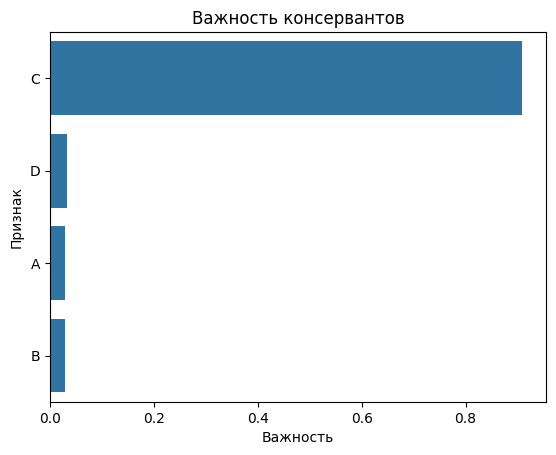

Наибольшее влияние на порчу корма оказывает: C


In [22]:
X_food = data.drop('Spoiled', axis=1)
y_food = data['Spoiled']

food_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

food_model.fit(X_food, y_food)

feature_importance = pd.DataFrame({
    'Признак': X_food.columns,
    'Важность': food_model.feature_importances_
}).sort_values(by='Важность', ascending=False)

display(feature_importance)

sns.barplot(data=feature_importance, x='Важность', y='Признак')
plt.title('Важность консервантов')
plt.show()

main_preservative = feature_importance.iloc[0]['Признак']
print('Наибольшее влияние на порчу корма оказывает:', main_preservative)